In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Nadam
from tensorflow.keras.datasets import mnist
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Load and preprocess MNIST dataset
(x_train, y_train), (x_val, y_val) = mnist.load_data()
x_train = x_train / 255.0  # Normalize
x_val = x_val / 255.0  # Normalize
y_train = tf.keras.utils.to_categorical(y_train, 10)  # One-hot encoding
y_val = tf.keras.utils.to_categorical(y_val, 10)  # One-hot encoding

Training with SGD optimizer...


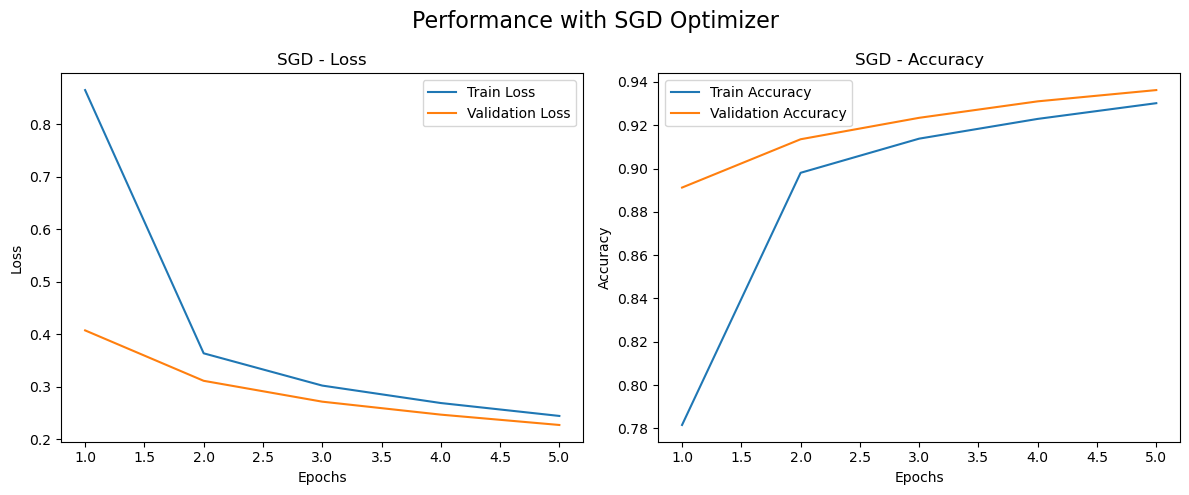

Training with Adam optimizer...


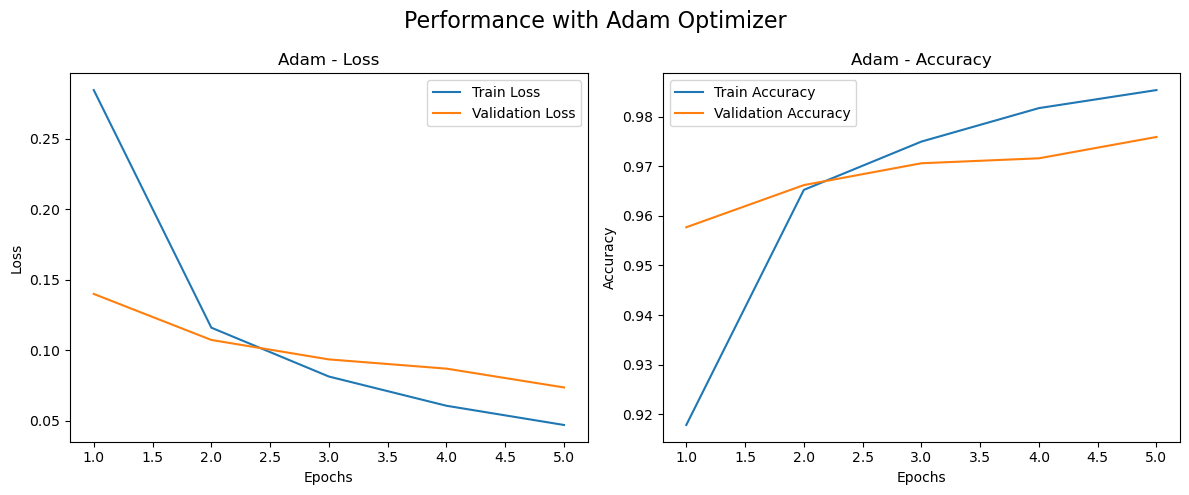

Training with RMSprop optimizer...


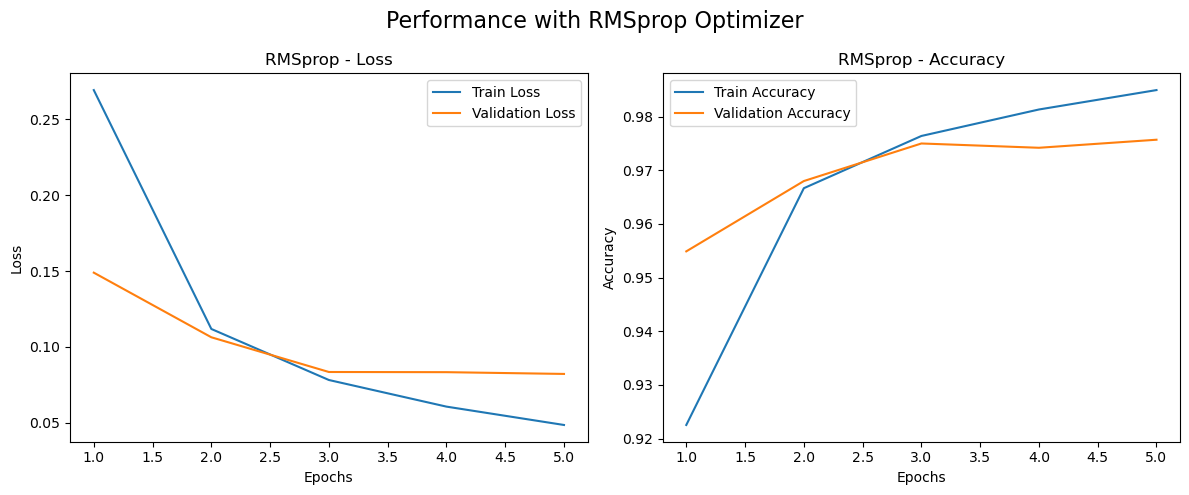

Training with Adagrad optimizer...


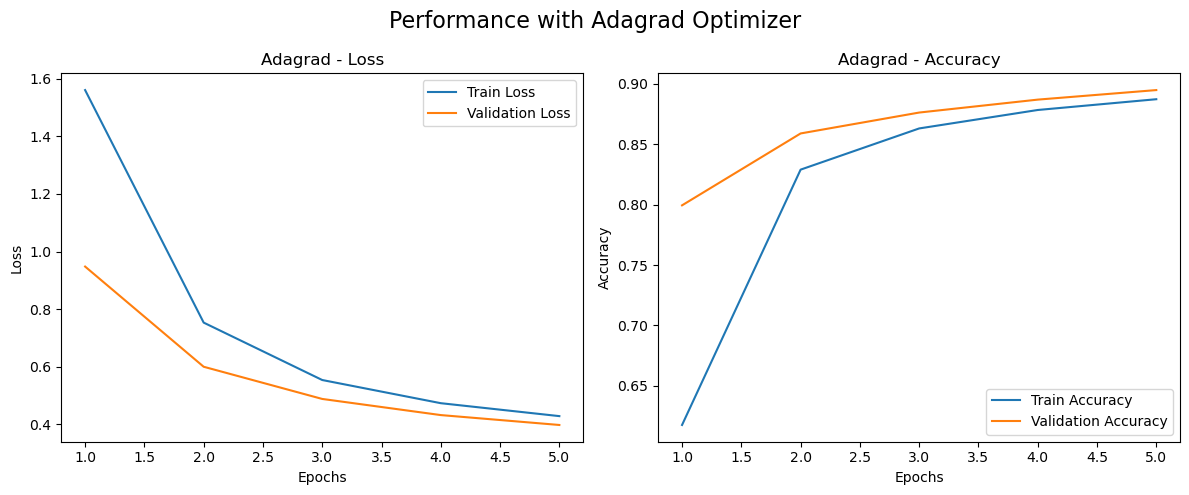

Training with Nadam optimizer...


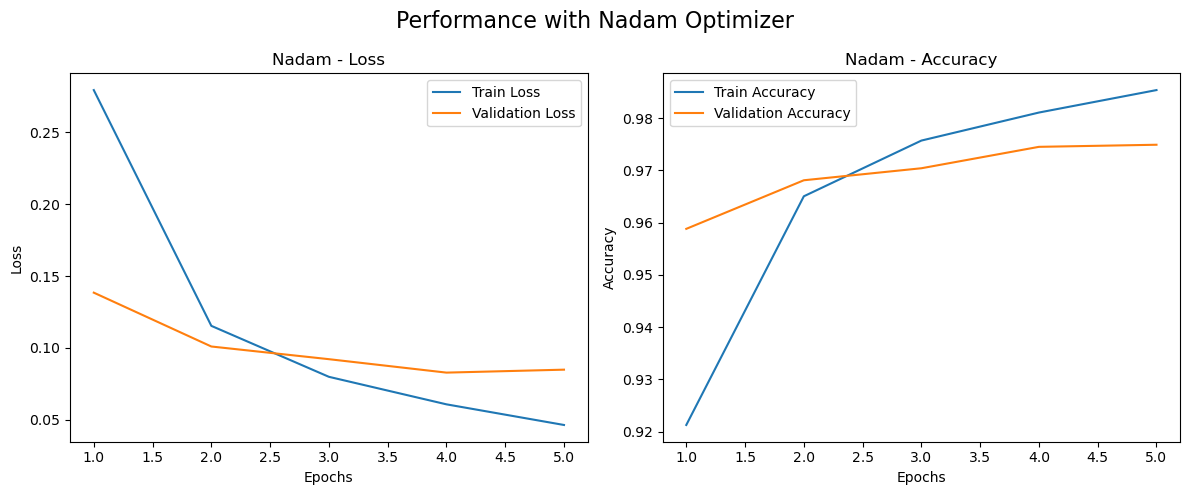

In [11]:
# Define the MLP model
def create_model():
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Define the list of optimizers to test
optimizers = {
    "SGD": SGD(),
    "Adam": Adam(),
    "RMSprop": RMSprop(),
    "Adagrad": Adagrad(),
    "Nadam": Nadam() #Nesterov-accelerated Adaptive Moment Estimation
}

# Results storage
results = []

# Train and evaluate the model with each optimizer
for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")
    model = create_model()
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    history = model.fit(
        x_train, y_train, 
        validation_data=(x_val, y_val),
        epochs=5, 
        batch_size=64, 
        verbose=0  # Suppress detailed logs for cleaner output
    )
    # Collect results
    train_loss = history.history['loss'][-1]
    train_accuracy = history.history['accuracy'][-1]
    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_accuracy'][-1]
    results.append({
        "Optimizer": opt_name,
        "Train Loss": train_loss,
        "Train Accuracy": train_accuracy,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy
    })

    # Plot Loss and Accuracy
    epochs = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title(f'{opt_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{opt_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.suptitle(f'Performance with {opt_name} Optimizer', fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)

print(results_df)

# Find and print the best optimizer
best_optimizer = results_df.loc[results_df["Validation Accuracy"].idxmax()]
print("\nBest Optimizer:")
print(best_optimizer)

  Optimizer  Train Loss  Train Accuracy  Validation Loss  Validation Accuracy
0       SGD    0.244469        0.930150         0.227274               0.9362
1      Adam    0.047051        0.985350         0.073675               0.9759
2   RMSprop    0.048465        0.984950         0.082129               0.9757
3   Adagrad    0.428516        0.887233         0.397763               0.8948
4     Nadam    0.046207        0.985367         0.084747               0.9749

Best Optimizer:
Optimizer                  Adam
Train Loss             0.047051
Train Accuracy          0.98535
Validation Loss        0.073675
Validation Accuracy      0.9759
Name: 1, dtype: object
